<a href="https://colab.research.google.com/github/Siddanth-tech/Eda-25BAI0031/blob/main/Assignment_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
np.random.seed(42)

In [3]:
dates = pd.date_range(start='2014-01-01', periods=120, freq='MS')

In [4]:
time_index = np.arange(len(dates))
trend = 100 + 2.5 * time_index
seasonality = 30 * np.sin(2 * np.pi * time_index / 12) + 15 * np.cos(2 * np.pi * time_index / 12)
noise = np.random.normal(loc=0, scale=10, size=len(dates))

passenger_counts = np.round(trend + seasonality + noise).astype(int)

df = pd.DataFrame({
    'Date': dates,
    'Passengers': passenger_counts
})


In [5]:
print("Dataset Shape:", df.shape)

Dataset Shape: (120, 2)


In [7]:
df_indexed = df.set_index('Date')

In [8]:
print("\nRandom Sample (5 rows):")
print(df_indexed.sample(5, random_state=42))


Random Sample (5 rows):
            Passengers
Date                  
2017-09-01         162
2017-12-01         226
2014-05-01         126
2018-08-01         219
2016-03-01         187


In [9]:
print("\nTime-based Indexing (Year 2018):")
print(df_indexed.loc['2018'].head())
print("\nTime-based Slicing (Jan 2019 to June 2019):")
print(df_indexed.loc['2019-01':'2019-06'])


Time-based Indexing (Year 2018):
            Passengers
Date                  
2018-01-01         238
2018-02-01         233
2018-03-01         262
2018-04-01         254
2018-05-01         242

Time-based Slicing (Jan 2019 to June 2019):
            Passengers
Date                  
2019-01-01         260
2019-02-01         279
2019-03-01         277
2019-04-01         276
2019-05-01         287
2019-06-01         278


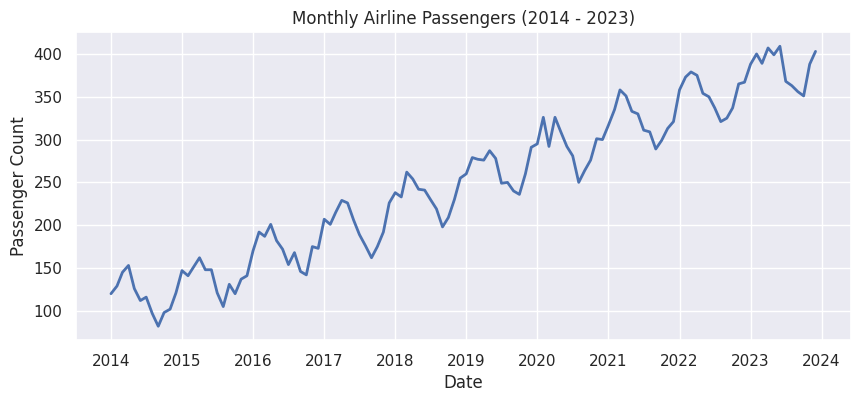

In [10]:
sns.set_theme(style="darkgrid")
plt.figure(figsize=(10, 4))
sns.lineplot(data=df_indexed, x=df_indexed.index, y='Passengers', color='b', linewidth=2)
plt.title('Monthly Airline Passengers (2014 - 2023)')
plt.xlabel('Date')
plt.ylabel('Passenger Count')
plt.show()

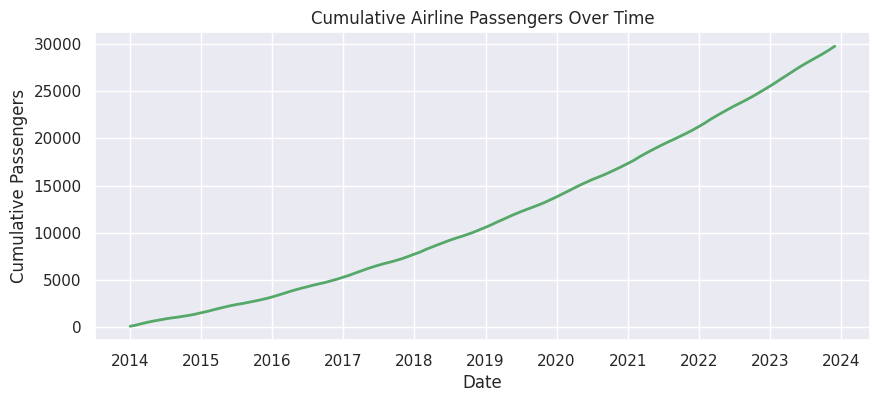

In [11]:
df_indexed['Cumulative_Passengers'] = df_indexed['Passengers'].cumsum()
plt.figure(figsize=(10, 4))
sns.lineplot(data=df_indexed, x=df_indexed.index, y='Cumulative_Passengers', color='g', linewidth=2)
plt.title('Cumulative Airline Passengers Over Time')
plt.xlabel('Date')
plt.ylabel('Cumulative Passengers')
plt.show()